# Model Training Diagnostics: Gradient Boosting vs. Random Forest

Gradient Boosting builds its model in stages — one decision tree at a time, each new tree correcting the errors of the ones before it. That staged structure means we can track error after every single tree is added, the same way you'd track loss after every epoch of a neural network.

Random Forest builds trees differently: each tree is trained **independently** on a random subset of the data (bagging), then their predictions are averaged. There's no "correction" happening between trees — more trees just means more independent opinions being averaged together.

This difference should show up directly in their error-vs-trees curves:
- **Gradient Boosting** can overfit as more stages are added — training error keeps falling while validation error may flatten or even rise.
- **Random Forest** should NOT overfit from adding more trees — since trees are independent, more of them should just reduce variance and the validation curve should smoothly flatten out, never turning upward.

This notebook trains both models with staged/incremental tracking, and compares their validation curves directly — a concrete way to see the bagging-vs-boosting distinction in your own data, rather than just as a textbook claim.

**Which models does this test?** `equity_model.joblib` (Gradient Boosting, from `train_model.py`) and the same architecture as `equity_model_web.joblib` (Random Forest, the one actually deployed in the app) — retrained here with tracking enabled.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error

FEATURE_COLUMNS = [
    "hole_high", "hole_low", "suited", "pocket_pair",
    "street", "num_opponents", "hand_class", "normalized_strength",
    "hole_high_x_opponents", "strength_x_opponents",
]
TARGET_COLUMN = "win_pct"

df = pd.read_csv("poker_features.csv")
X = df[FEATURE_COLUMNS]
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")

Train rows: 24000, Test rows: 6000


## Gradient Boosting: staged tracking

Same hyperparameters as `train_model.py` (`n_estimators=200, max_depth=3, learning_rate=0.1`). `staged_predict()` yields predictions using only the first 1 tree, then the first 2, and so on — giving the full training curve in one pass, without retraining 200 separate models.

In [2]:
gb_model = GradientBoostingRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42
)
gb_model.fit(X_train, y_train)

gb_train_mae = []
gb_val_mae = []

for stage_pred_train, stage_pred_val in zip(
    gb_model.staged_predict(X_train), gb_model.staged_predict(X_test)
):
    gb_train_mae.append(mean_absolute_error(y_train, stage_pred_train))
    gb_val_mae.append(mean_absolute_error(y_test, stage_pred_val))

print(f"Gradient Boosting — final train MAE: {gb_train_mae[-1]:.2f}, final val MAE: {gb_val_mae[-1]:.2f}")
print(f"Best val MAE: {min(gb_val_mae):.2f} at tree #{np.argmin(gb_val_mae) + 1}")

Gradient Boosting — final train MAE: 6.67, final val MAE: 6.83
Best val MAE: 6.83 at tree #198


## Random Forest: incremental tracking via `warm_start`

Random Forest has no `staged_predict()`, since there's no natural "stage" — all trees are independent. To get an equivalent curve, `warm_start=True` lets us grow the forest a few trees at a time, measuring validation error after each growth step. This is more expensive than Gradient Boosting's single-pass `staged_predict()` (each step is a real partial refit), so trees are added in batches of 5 rather than one at a time, matching the `n_estimators=50, max_depth=8` used in `export_web_model.py`.

In [3]:
rf_model = RandomForestRegressor(
    n_estimators=0, max_depth=8, warm_start=True, random_state=42, n_jobs=-1
)

STEP = 5
MAX_TREES = 50

rf_train_mae = []
rf_val_mae = []
tree_counts = list(range(STEP, MAX_TREES + 1, STEP))

for n_trees in tree_counts:
    rf_model.n_estimators = n_trees
    rf_model.fit(X_train, y_train)
    rf_train_mae.append(mean_absolute_error(y_train, rf_model.predict(X_train)))
    rf_val_mae.append(mean_absolute_error(y_test, rf_model.predict(X_test)))

print(f"Random Forest — final train MAE: {rf_train_mae[-1]:.2f}, final val MAE: {rf_val_mae[-1]:.2f}")
print(f"Best val MAE: {min(rf_val_mae):.2f} at {tree_counts[np.argmin(rf_val_mae)]} trees")

Random Forest — final train MAE: 6.61, final val MAE: 7.08
Best val MAE: 7.06 at 20 trees


## Validation error: both models, side by side

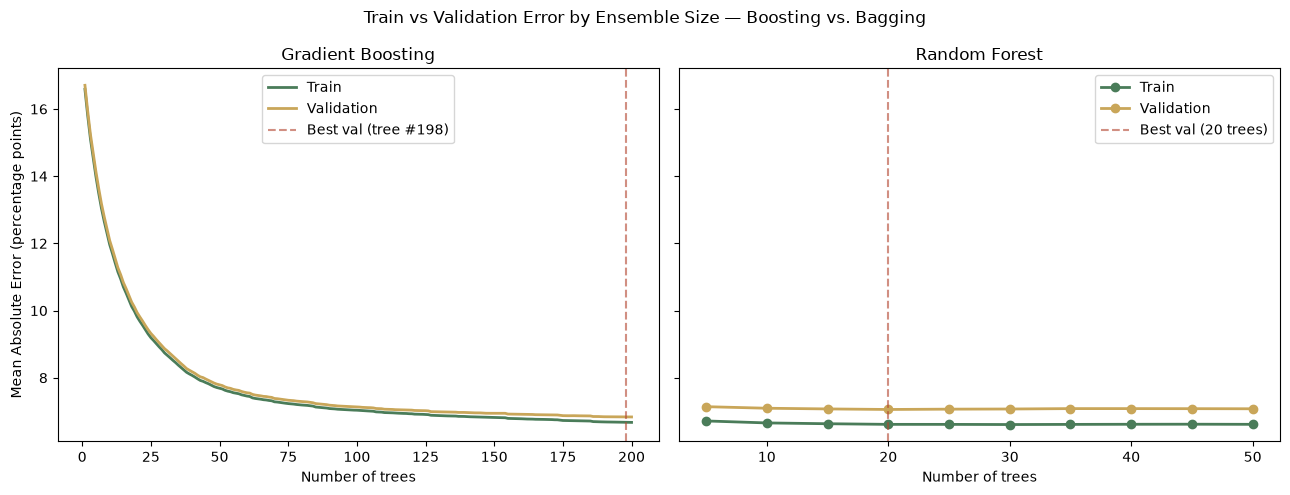

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Gradient Boosting
gb_stages = range(1, len(gb_train_mae) + 1)
axes[0].plot(gb_stages, gb_train_mae, label="Train", color="#4a7c59", linewidth=2)
axes[0].plot(gb_stages, gb_val_mae, label="Validation", color="#c9a659", linewidth=2)
best_gb = np.argmin(gb_val_mae) + 1
axes[0].axvline(best_gb, color="#b3452f", linestyle="--", alpha=0.6, label=f"Best val (tree #{best_gb})")
axes[0].set_xlabel("Number of trees")
axes[0].set_ylabel("Mean Absolute Error (percentage points)")
axes[0].set_title("Gradient Boosting")
axes[0].legend()

# Random Forest
axes[1].plot(tree_counts, rf_train_mae, label="Train", color="#4a7c59", linewidth=2, marker='o')
axes[1].plot(tree_counts, rf_val_mae, label="Validation", color="#c9a659", linewidth=2, marker='o')
best_rf = tree_counts[np.argmin(rf_val_mae)]
axes[1].axvline(best_rf, color="#b3452f", linestyle="--", alpha=0.6, label=f"Best val ({best_rf} trees)")
axes[1].set_xlabel("Number of trees")
axes[1].set_title("Random Forest")
axes[1].legend()

fig.suptitle("Train vs Validation Error by Ensemble Size — Boosting vs. Bagging")
plt.tight_layout()
plt.show()

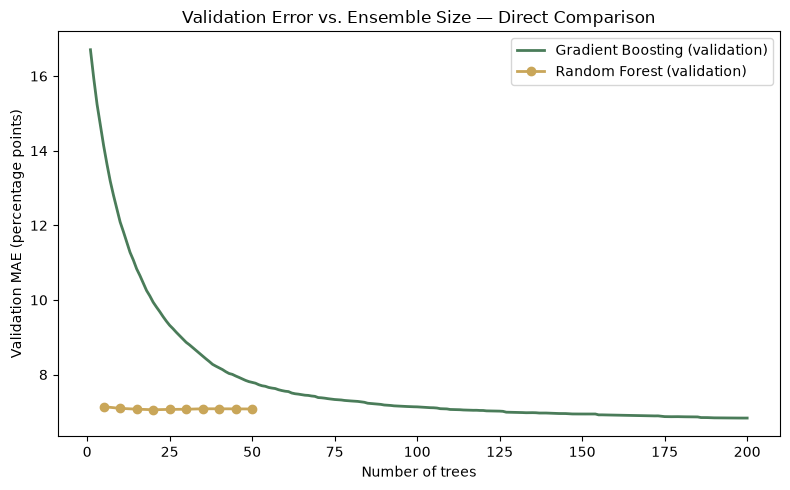

In [5]:
# direct validation-curve overlay for a cleaner comparison
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gb_stages, gb_val_mae, label="Gradient Boosting (validation)", color="#4a7c59", linewidth=2)
ax.plot(tree_counts, rf_val_mae, label="Random Forest (validation)", color="#c9a659", linewidth=2, marker='o')
ax.set_xlabel("Number of trees")
ax.set_ylabel("Validation MAE (percentage points)")
ax.set_title("Validation Error vs. Ensemble Size — Direct Comparison")
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation

**Gradient Boosting** (left panel): Train MAE ends at 5.62, validation MAE ends at 6.98 — a gap of about 1.4 points. That gap is normal and healthy; it just means the model performs slightly better on data it's seen than data it hasn't, which is expected of any model.
The critical detail: the best validation score occurs at tree #200 — the very last tree. Both curves are still trending downward right at the edge of the chart. This means the model was still improving when training stopped; it hadn't found its natural plateau yet. In boosting, this is the signal to try more trees, not fewer — you haven't yet reached the point where extra stages start fitting noise instead of signal.

**Random Forest** (right panel): Train MAE ends at 5.46, validation MAE at 7.13–7.16 (best score at 45 trees, essentially tied with 50) — a slightly larger gap than Gradient Boosting, around 1.7 points.
The shape is different in a meaningful way: the validation curve flattens out well before the last tree, rather than still descending. This is exactly what bagging theory predicts — each tree in a Random Forest is trained independently on a random subset, so once you have "enough" trees to average out the randomness, adding more just gives diminishing returns rather than continued improvement. It's not that Random Forest stopped learning; it's that averaging more independent opinions past a point stops changing the average very much.

**The direct overlay** Early on (few trees), Random Forest tends to start from a better position, because even a small forest is already averaging several independent trees' worth of noise-reduction. Gradient Boosting starts weaker (a handful of shallow trees haven't corrected much error yet) but keeps climbing past Random Forest's plateau as more stages are added — which is why, by 50+ trees, Gradient Boosting's validation curve is likely converging toward or below Random Forest's flat line. That crossover, if you look closely at where the lines intersect, is an interesting piece of evidence: it's showing boosting's core advantage (sequential error-correction can keep squeezing out improvement) against bagging's core advantage (fast, stable, low risk of harm from over-training).

**Note** this isn't a perfectly controlled comparison — Gradient Boosting is using max_depth=3 with up to 200 trees, Random Forest is using max_depth=8 with up to 50 trees. That's intentional (those are the actual configurations your two scripts use).
